In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

'pwd' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
#Simulation data

p_hat = np.random.normal(0.5, 0.15, 600)
p_hat = np.clip(p_hat, 0, 1)

# Generate binary Y based on the probability p_hat
Y = np.random.binomial(1, p_hat)
data = np.column_stack((p_hat, Y))
data

array([[0.29363893, 1.        ],
       [0.30431733, 0.        ],
       [0.48835712, 1.        ],
       ...,
       [0.40003948, 0.        ],
       [0.37909197, 0.        ],
       [0.58656599, 1.        ]])

## Start of function
### Input data is a 2D array, with the first column to be the predicted value, second column is the binary response. And distance data is the given 600 x 600 matrix, which will be read from csv file. Tst size and train size decides the traing size, training size and calibration size. rs is a seed parameter for replicability. number_nearest is used to set the nearest number will doing conformal prediction

In [3]:
# Turncation function, just make sure the upper and lower bound of the CI is within [0,1]
def truncate_number(num):
    return max(0, min(1, num))

In [4]:
distance_data = np.load("ENZYMES_maxscale_10_sublevel_filtration_wasserstein_distances.npy")

FileNotFoundError: [Errno 2] No such file or directory: 'ENZYMES_maxscale_10_sublevel_filtration_wasserstein_distances.npy'

In [106]:
def CP_exchangeable(data, distance_data, tst_size = 0.2,train_size=0.5, rs=42, number_nearest=50):
    rd_seed = rs
    data = pd.DataFrame(data)
    data.columns = ["p_hat","Y"]
    tst_data, df_obs = train_test_split(data, train_size=tst_size, random_state=rs)
    seed = np.random.randint(1, 1000000, size=tst_data.shape[0])
    rate =  train_size
    tst_output = np.zeros((tst_data.shape[0], 6))
    tst_index = tst_data.index

    for i in range(0,tst_data.shape[0]):
        #Split the observation data
        df_train, df_cal = train_test_split(df_obs, train_size=rate, random_state=seed[i])
        df_train_index = df_train.index
        df_cal_index = df_cal.index
        
        Cs = np.zeros((df_cal.shape[0], 2))
        for j in range(1,df_cal.shape[0]):
            temp_cal_index = df_cal[j]
            p_hat = data.iloc[temp_cal_index,1]
            temp_nearest_index = pd.DataFrame(distance_data).loc[temp_cal_index,df_train_index].nsmallest(number_nearest).index
            p_t = np.mean(data.iloc[temp_nearest_index,1])
            temp_Cs = p_t - p_hat
            Cs[j,0] = temp_Cs
            Cs[j,1] = df_cal.iloc[j,df_cal.shape[1]-1]

        
        fix_sen_quantile_95 = np.percentile(Cs[Cs[:, 1] == 0], 95)    
        fix_sen_quantile_5 = np.percentile(Cs[Cs[:, 1] == 0], 5)
        fix_spe_quantile_95 = np.percentile(Cs[Cs[:, 1] == 1], 95)    
        fix_spe_quantile_5 = np.percentile(Cs[Cs[:, 1] == 1], 5)

        
        tst_output[i,0] = tst_data.iloc[i,-2]
        tst_output[i,1] = truncate_number(tst_data.iloc[i,-2] + fix_sen_quantile_95)
        tst_output[i,2] = truncate_number(tst_data.iloc[i,-2] + fix_sen_quantile_5)
        tst_output[i,1] = truncate_number(tst_data.iloc[i,-2] + fix_spe_quantile_95)
        tst_output[i,2] = truncate_number(tst_data.iloc[i,-2] + fix_spe_quantile_5)
        tst_output[i,3] = tst_data.iloc[i,-1]
    
    tst_output =  pd.DataFrame(tst_output)
    tst_output.columns = ["p_hat","fix_sen_upper_p","fix_sen_lower_p","fix_spe_upper_p","fix_spe_lower_p","Y"]

    return tst_output

In [101]:
def CP_non_exchangeable(data, distance_data, tst_size = 0.2,train_size=0.5, rs=42, number_nearest=50):
    rd_seed = rs
    data = pd.DataFrame(data)
    data.columns = ["p_hat","Y"]
    tst_data, df_obs = train_test_split(data, train_size=tst_size, random_state=rs)
    seed = np.random.randint(1, 1000000, size=tst_data.shape[0])
    rate =  train_size
    tst_output = np.zeros((tst_data.shape[0], 6))
    tst_index = tst_data.index

    for i in range(0,tst_data.shape[0]):
        #Split the observation data
        df_train, df_cal = train_test_split(df_obs, train_size=rate, random_state=seed[i])
        df_train_index = df_train.index
        df_cal_index = df_cal.index

        #Distance matrix: From tst point to calibration data and select the neighborhood of the tst point
        tst_cal_dis_data = pd.DataFrame(distance_data).loc[tst_index[i],df_cal_index]
        tst_cal_nearest_index = tst_cal_dis_data.nsmallest(number_nearest).index
        selected_df_cal = data.iloc[tst_cal_nearest_index,:]
        selected_df_cal_index = selected_df_cal.index
        
        Cs = np.zeros((selected_df_cal.shape[0], 2))
        for j in range(1,selected_df_cal.shape[0]):
            temp_cal_index = selected_df_cal_index[j]
            p_hat = data.iloc[temp_cal_index,1]
            temp_nearest_index = pd.DataFrame(distance_data).loc[temp_cal_index,df_train_index].nsmallest(number_nearest).index
            p_t = np.mean(data.iloc[temp_nearest_index,1])
            temp_Cs = p_t - p_hat
            Cs[j,0] = temp_Cs
            Cs[j,1] = selected_df_cal.iloc[j,df_cal.shape[1]-1]

        
        fix_sen_quantile_95 = np.percentile(Cs[Cs[:, 1] == 0], 95)    
        fix_sen_quantile_5 = np.percentile(Cs[Cs[:, 1] == 0], 5)
        fix_spe_quantile_95 = np.percentile(Cs[Cs[:, 1] == 1], 95)    
        fix_spe_quantile_5 = np.percentile(Cs[Cs[:, 1] == 1], 5)

        
        tst_output[i,0] = tst_data.iloc[i,-2]
        tst_output[i,1] = truncate_number(tst_data.iloc[i,-2] + fix_sen_quantile_95)
        tst_output[i,2] = truncate_number(tst_data.iloc[i,-2] + fix_sen_quantile_5)
        tst_output[i,1] = truncate_number(tst_data.iloc[i,-2] + fix_spe_quantile_95)
        tst_output[i,2] = truncate_number(tst_data.iloc[i,-2] + fix_spe_quantile_5)
        tst_output[i,3] = tst_data.iloc[i,-1]
    
    tst_output =  pd.DataFrame(tst_output)
    tst_output.columns = ["p_hat","fix_sen_upper_p","fix_sen_lower_p","fix_spe_upper_p","fix_spe_lower_p","Y"]

    return tst_output


In [98]:
result = CP_exchangeable(data, distance_data, tst_size = 0.2,train_size=0.5, rs=42, number_nearest=50)

In [174]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr1, tpr1, _ = roc_curve(result['Y'], result['fix_sen_upper_p'])
roc_auc_p = auc(fpr1, tpr1)

fpr2, tpr2, _ = roc_curve(result['Y'], result['fix_sen_lower_p'])
roc_auc_fix = auc(fpr2, tpr2)

fpr3, tpr3, _ = roc_curve(result['Y'], result['fix_spe_upper_p'])
roc_auc_p = auc(fpr3, tpr3)

fpr4, tpr4, _ = roc_curve(result['Y'], result['fix_spe_lower_p'])
roc_auc_fix = auc(fpr4, tpr4)

I:\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
I:\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
I:\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
I:\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


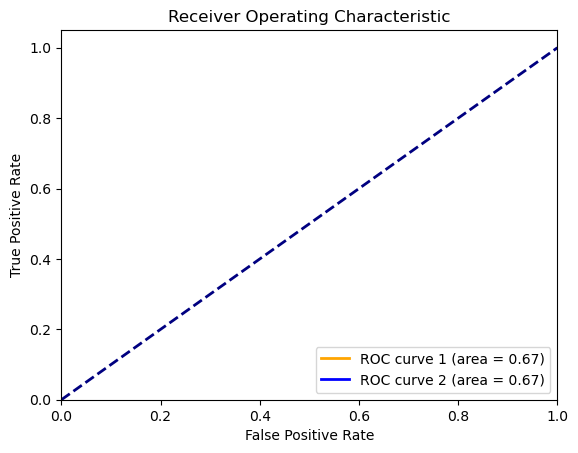

In [176]:
plt.figure()
lw = 2  # Line width
plt.plot(fpr1, tpr1, color='orange', lw=lw, label='ROC curve 1 (area = %0.2f)' % roc_auc1)
plt.plot(fpr2, tpr2, color='blue', lw=lw, label='ROC curve 2 (area = %0.2f)' % roc_auc2)

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
def CP_exchangeable(data, distance_data, tst_size=0.2, train_size=0.5, rs=42, number_nearest=50):
    np.random.seed(rs)
    # Assuming data is a NumPy array with 2 columns: ["p_hat", "Y"]
    # Splitting the data into test and observation datasets
    tst_data_indices, df_obs_indices = train_test_split(np.arange(data.shape[0]), train_size=tst_size, random_state=rs)
    tst_data = data[tst_data_indices, :]
    df_obs = data[df_obs_indices, :]
    seeds = np.random.randint(1, 1000000, size=tst_data.shape[0])
    
    tst_output = np.zeros((tst_data.shape[0], 6))  # Preparing output structure

    for i, seed in enumerate(seeds):
        np.random.seed(seed)
        # Splitting the observation data into training and calibration datasets
        df_train_indices, df_cal_indices = train_test_split(df_obs_indices, train_size=train_size, random_state=seed)
        
        Cs = np.zeros((len(df_cal_indices), 2))
        for j, cal_index in enumerate(df_cal_indices):
            p_hat = data[cal_index, 0]
            # Calculate distances and find nearest indices
            distances = distance_data[cal_index, df_train_indices]
            nearest_indices = np.argsort(distances)[:number_nearest]
            p_t = np.mean(data[df_train_indices][nearest_indices, 0])
            temp_Cs = p_t - p_hat
            Cs[j, 0] = temp_Cs
            Cs[j, 1] = data[cal_index, 1]
        
        # Quantile calculations
        fix_sen_quantile_95 = np.percentile(Cs[Cs[:, 1] == 0, 0], 95)
        fix_sen_quantile_5 = np.percentile(Cs[Cs[:, 1] == 0, 0], 5)
        fix_spe_quantile_95 = np.percentile(Cs[Cs[:, 1] == 1, 0], 95)
        fix_spe_quantile_5 = np.percentile(Cs[Cs[:, 1] == 1, 0], 5)
        
        tst_output[i, 0] = tst_data[i, 0]
        tst_output[i, 1] = truncate_number(tst_data[i, 0] + fix_sen_quantile_95)
        tst_output[i, 2] = truncate_number(tst_data[i, 0] + fix_sen_quantile_5)
        tst_output[i, 3] = truncate_number(tst_data[i, 0] + fix_spe_quantile_95)
        tst_output[i, 4] = truncate_number(tst_data[i, 0] + fix_spe_quantile_5)
        tst_output[i, 5] = tst_data[i, 1]

    return tst_output

In [6]:
with open('data.npy', 'rb') as f:
    a = np.load(f)

In [7]:
a

array([[0.42434177, 0.        ],
       [0.47644037, 0.        ],
       [0.4610199 , 0.        ],
       ...,
       [0.48824492, 1.        ],
       [0.40104902, 1.        ],
       [0.85597318, 1.        ]])